In [1]:
"""cifar10 hp-tuning CL-vae: interactive notebook experiment.

Legacy Hyperas experiment template. create_data supplies image or stored-feature arrays,
and create_model contains double-brace search expressions that Hyperas expands before
execution. These templates retain the historical helper signatures and optimizer options
written in their cells.

The search choices, best-score globals, trial counter, dataset/model paths, and fit
arguments below are its inputs. Local function docstrings explain each objective and
preprocessing branch. Outputs include trial losses, logs, and saved best models where
the objective explicitly writes them. Running cells may initialize GPU resources,
load/download data, train models, and overwrite configured artifact paths.
"""

from __future__ import print_function

import os


os.chdir("../")

In [2]:
from hyperopt import STATUS_OK, Trials, tpe
from hyperas.distributions import choice, uniform, loguniform
from hyperas import optim

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, metrics
from tensorflow.keras.datasets import cifar10

from sklearn.model_selection import train_test_split

import numpy as np

from learner import continually_learn
from model import get_compile_args, get_callbacks
from masked_loss import MaskedLoss
from dataloader import load_cifar10
from common.utils import (hyperas_path, i, init,
                        best_score, save_logs)

In [3]:
def create_data():
    """Load three aligned CIFAR10 feature representations for replay tuning.

    Initializes the notebook runtime and invokes the loader three times. Corresponding
    rows are assumed to remain aligned across preprocessing choices. Validation/test
    outputs are discarded.

    Args:
        None.

    Returns:
        tuple[np.ndarray, ...]: Default, normalize, and min-max training features
        followed by one-hot training labels from the first load.
    """

    init()

    feature_train0, y_train, *_ = load_cifar10(return_features=True, onehot_labels=True, verbose=0)
    feature_train1, *_ = load_cifar10(return_features=True, preprocess="normalize", verbose=0)
    feature_train2, *_ = load_cifar10(return_features=True, preprocess="min-max", verbose=0)

    return feature_train0, feature_train1, feature_train2, y_train

In [4]:
def create_model(feature_train0, feature_train1, feature_train2, y_train):
    """Score one legacy CIFAR10 continual VAE-replay Hyperas treatment.

    The sampled decoder activation selects the loader preprocessing string; all feature-
    array arguments and y_train are retained only for the Hyperas data signature. The
    template calls continually_learn using historical use_vae/vae_kwargs options, so it
    requires the API version expected by this notebook. It varies reconstruction loss
    and training/replay counts, updates best_score and i, and appends logs; it does not
    save a model in the improvement branch.

    Args:
        feature_train0 (np.ndarray): Training features in the loader default
            representation, paired with a linear decoder.
        feature_train1 (np.ndarray): Training features loaded with
            preprocess="normalize", paired with a tanh decoder.
        feature_train2 (np.ndarray): Training features loaded with preprocess="min-max",
            paired with a sigmoid decoder.
        y_train (np.ndarray): One-hot training labels shaped (N, 10), supplied by
            create_data but unused by this legacy objective.

    Returns:
        dict[str, object]: loss=-final_continual_accuracy, status=STATUS_OK, and
        model=None.
    """

    global best_score, i  


    last_actv = {{choice(["linear", "tanh", "sigmoid"])}}
    loss_choice = {{choice(["mae", "mse"])}}
    train_num = {{choice([-1, 500, 1_000, 2_500, 5_000, 10_000, 20_000])}}
    samples_per_class = {{choice([100, 250, 500, 1_000, 1_500, 2_500, 5_000])}} 


    # Linear decoder output uses the default feature representation.
    if last_actv == "linear":
        feature_train = feature_train0
        preprocess = ""
    # Tanh decoder output uses the normalize feature representation.
    elif last_actv == "tanh":
        feature_train = feature_train1
        preprocess = "normalize"
    # Sigmoid decoder output uses the min-max feature representation.
    elif last_actv == "sigmoid":
        feature_train = feature_train2
        preprocess = "min-max"


    log_name = "cifar10_cl_vae_00"
    save_logs(log_name, i, 
            search_space=[last_actv, 
                        loss_choice, train_num, samples_per_class], 
            names=["last_actv", 
                "loss_choice", "train_num", "samples_per_class"])

    acc_list = continually_learn(
        class_num=10, 
        load_dataset_fn=load_cifar10, 
        load_dataset_fn_kwargs={"onehot_labels": True, "preprocess": preprocess}, 
        remove_prev_classes=True, 
        keep_same_model=True, 
        tuned_model_path=os.path.join(hyperas_path, "cifar10_dnn_model_00.h5"), 
        compile_args=get_compile_args(
            optimizer=optimizers.Adam(learning_rate=5e-5), # optimizer1
            loss=MaskedLoss(loss_type=loss_choice)
        ), 
        use_vae=True, 
        vae_kwargs={
            "train_num": train_num,
            "samples_per_class": samples_per_class,
        },
        plot_results=False,
        verbose=0
    )
    score = acc_list[-1]

    # Record a new best score only when this trial improves the previous maximum.
    if score > best_score:
        best_score = score

    save_logs(log_name, i, metrics={
            "score": score,
            "best_score": best_score})

    i += 1


    return {"loss": -score, "status": STATUS_OK, "model": None}

In [6]:
best_run, best_model = optim.minimize(
    model=create_model,
    data=create_data,
    algo=tpe.suggest,
    max_evals=200,
    trials=Trials(),
    notebook_name="notebooks/cifar10 hp-tuning CL-vae"
)

>>> Imports:
#coding=utf-8

from __future__ import print_function

try:
    import os
except:
    pass

try:
    from hyperopt import STATUS_OK, Trials, tpe
except:
    pass

try:
    from hyperas.distributions import choice, uniform, loguniform
except:
    pass

try:
    from hyperas import optim
except:
    pass

try:
    import tensorflow as tf
except:
    pass

try:
    from tensorflow.keras import layers, models, optimizers, metrics
except:
    pass

try:
    from tensorflow.keras.datasets import cifar10
except:
    pass

try:
    from sklearn.model_selection import train_test_split
except:
    pass

try:
    import numpy as np
except:
    pass

try:
    from learner import continually_learn
except:
    pass

try:
    from model import get_compile_args, get_callbacks
except:
    pass

try:
    from masked_loss import MaskedLoss
except:
    pass

try:
    from dataloader import load_cifar10
except:
    pass

try:
    from common.utils import hyperas_path, i, init, best_score, save_

In [7]:
best_run

{'last_actv': 0, 'loss_choice': 0, 'samples_per_class': 2, 'train_num': 5}

--------------------------------------------------------------------------- Classes: [0, 1]
Epoch 1/100
63/63 [==============================] - 2s 20ms/step - loss: 0.1908 - accuracy: 0.8446 - val_loss: 0.2297 - val_accuracy: 0.9595
Epoch 2/100
63/63 [==============================] - 1s 14ms/step - loss: 0.0594 - accuracy: 0.9604 - val_loss: 0.1355 - val_accuracy: 0.9620
Epoch 3/100
63/63 [==============================] - 1s 15ms/step - loss: 0.0437 - accuracy: 0.9678 - val_loss: 0.0820 - val_accuracy: 0.9715
Epoch 4/100
63/63 [==============================] - 1s 14ms/step - loss: 0.0368 - accuracy: 0.9740 - val_loss: 0.0500 - val_accuracy: 0.9775
Epoch 5/100
63/63 [==============================] - 1s 14ms/step - loss: 0.0302 - accuracy: 0.9785 - val_loss: 0.0340 - val_accuracy: 0.9850
Epoch 6/100
63/63 [==============================] - 1s 14ms/step - loss: 0.0274 - accuracy: 0.9799 - val_loss: 0.0256 - val_accuracy: 0.9860
Epoch 7/100
63/63 [==============================] - 1s 

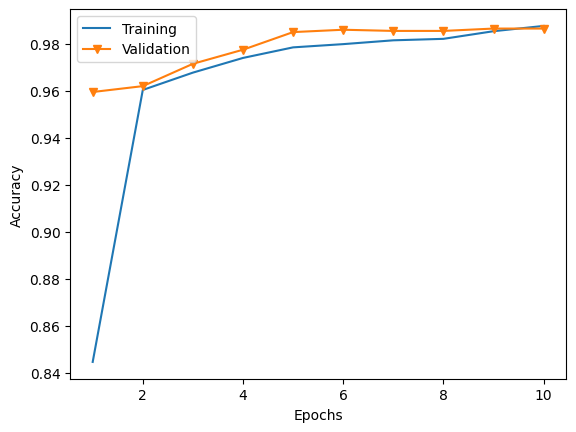

Epoch 1/10
20/20 [==============================] - 3s 52ms/step - loss: 0.7288 - recon_loss: 0.0472 - kl_loss: 0.9671 - decoder_accuracy: 0.9860
Epoch 2/10
20/20 [==============================] - 1s 39ms/step - loss: 0.0375 - recon_loss: 0.0284 - kl_loss: 0.0241 - decoder_accuracy: 0.9970
Epoch 3/10
20/20 [==============================] - 1s 40ms/step - loss: 0.0308 - recon_loss: 0.0283 - kl_loss: 0.0133 - decoder_accuracy: 0.9890
Epoch 4/10
20/20 [==============================] - 1s 39ms/step - loss: 0.0310 - recon_loss: 0.0282 - kl_loss: 0.0095 - decoder_accuracy: 0.9920
Epoch 5/10
20/20 [==============================] - 1s 40ms/step - loss: 0.0301 - recon_loss: 0.0283 - kl_loss: 0.0085 - decoder_accuracy: 0.5030
Epoch 6/10
20/20 [==============================] - 1s 38ms/step - loss: 0.0300 - recon_loss: 0.0280 - kl_loss: 0.0058 - decoder_accuracy: 1.0000
Epoch 7/10
20/20 [==============================] - 1s 41ms/step - loss: 0.0293 - recon_loss: 0.0278 - kl_loss: 0.0052 - dec

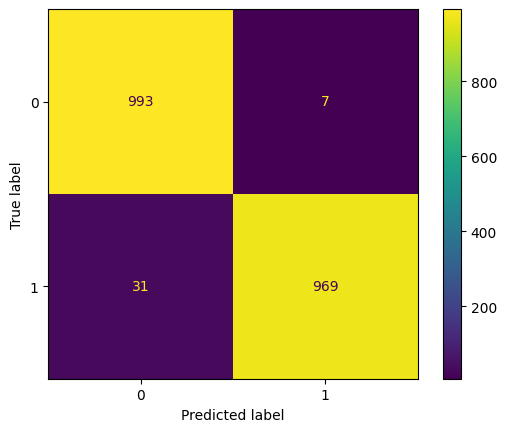

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2]
32/32 [==============================] - 0s 3ms/step
Epoch 1/100
40/40 [==============================] - 2s 25ms/step - loss: 0.2108 - accuracy: 0.7276 - val_loss: 0.0596 - val_accuracy: 0.9553
Epoch 2/100
40/40 [==============================] - 1s 15ms/step - loss: 0.0823 - accuracy: 0.9210 - val_loss: 0.0579 - val_accuracy: 0.9563
Epoch 3/100
40/40 [==============================] - 1s 15ms/step - loss: 0.0525 - accuracy: 0.9604 - val_loss: 0.0567 - val_accuracy: 0.9477
Epoch 4/100
40/40 [==============================] - 1s 17ms/step - loss: 0.0384 - accuracy: 0.9754 - val_loss: 0.0600 - val_accuracy: 0.9377
Epoch 5/100
40/40 [==============================] - 1s 15ms/step - loss: 0.0303 - accuracy: 0.9824 - val_loss: 0.0618 - val_accuracy: 0.9300
Epoch 6/100
40/40 [==============================] - 1s 18ms/step

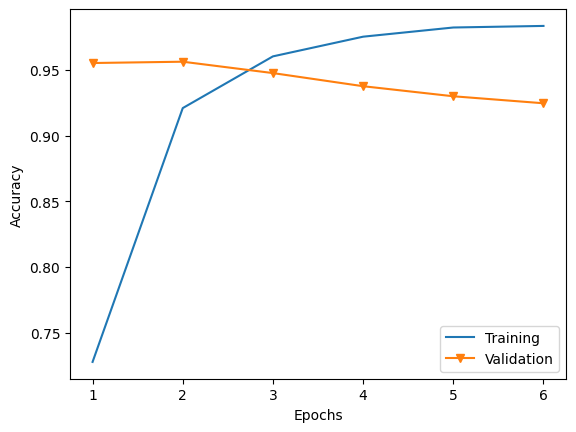

Epoch 1/10
20/20 [==============================] - 1s 56ms/step - loss: 0.3332 - recon_loss: 0.4155 - kl_loss: 0.0835 - decoder_accuracy: 0.3333
Epoch 2/10
20/20 [==============================] - 1s 45ms/step - loss: 0.0621 - recon_loss: 0.0429 - kl_loss: 8.6778e-04 - decoder_accuracy: 0.6647
Epoch 3/10
20/20 [==============================] - 1s 48ms/step - loss: 0.0271 - recon_loss: 0.0271 - kl_loss: 4.5669e-04 - decoder_accuracy: 0.6667
Epoch 4/10
20/20 [==============================] - 1s 46ms/step - loss: 0.0268 - recon_loss: 0.0264 - kl_loss: 3.3036e-04 - decoder_accuracy: 0.6667
Epoch 5/10
20/20 [==============================] - 1s 46ms/step - loss: 0.0264 - recon_loss: 0.0261 - kl_loss: 0.0022 - decoder_accuracy: 0.6667
Epoch 6/10
20/20 [==============================] - 1s 46ms/step - loss: 0.0269 - recon_loss: 0.0262 - kl_loss: 0.0016 - decoder_accuracy: 0.6667
Epoch 7/10
20/20 [==============================] - 1s 47ms/step - loss: 0.0261 - recon_loss: 0.0260 - kl_loss: 

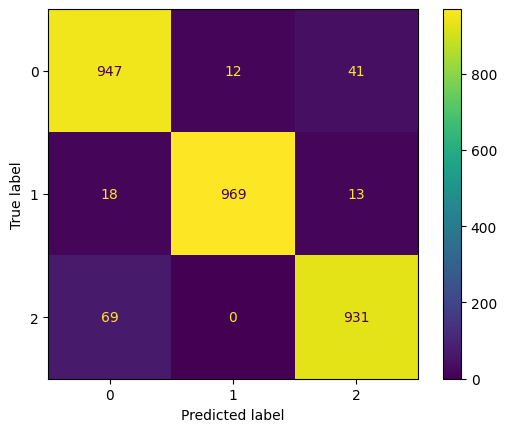

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3]
47/47 [==============================] - 0s 3ms/step
Epoch 1/100
43/43 [==============================] - 2s 26ms/step - loss: 0.1537 - accuracy: 0.7204 - val_loss: 0.0731 - val_accuracy: 0.8903
Epoch 2/100
43/43 [==============================] - 1s 15ms/step - loss: 0.0410 - accuracy: 0.9569 - val_loss: 0.0755 - val_accuracy: 0.8827
Epoch 3/100
43/43 [==============================] - 1s 15ms/step - loss: 0.0221 - accuracy: 0.9825 - val_loss: 0.0752 - val_accuracy: 0.8808
Epoch 4/100
43/43 [==============================] - 1s 16ms/step - loss: 0.0155 - accuracy: 0.9902 - val_loss: 0.0747 - val_accuracy: 0.8760
Epoch 5/100
43/43 [==============================] - 1s 15ms/step - loss: 0.0120 - accuracy: 0.9922 - val_loss: 0.0756 - val_accuracy: 0.8717
Epoch 6/100
43/43 [==============================] - 1s 16ms/s

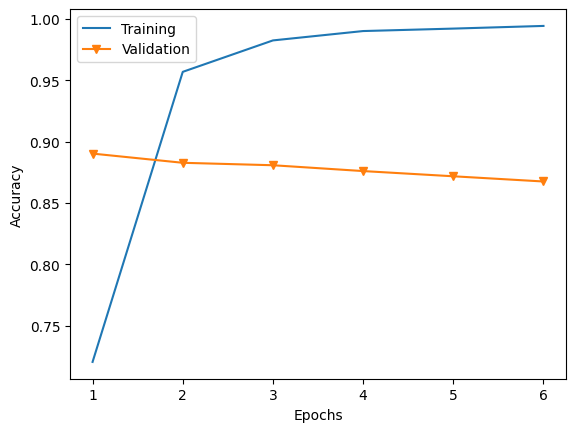

Epoch 1/10
20/20 [==============================] - 1s 60ms/step - loss: 0.0262 - recon_loss: 0.0250 - kl_loss: 0.0022 - decoder_accuracy: 0.7500
Epoch 2/10
20/20 [==============================] - 1s 50ms/step - loss: 0.0250 - recon_loss: 0.0248 - kl_loss: 0.0011 - decoder_accuracy: 0.7500
Epoch 3/10
20/20 [==============================] - 1s 51ms/step - loss: 0.0250 - recon_loss: 0.0246 - kl_loss: 4.2580e-04 - decoder_accuracy: 0.7500
Epoch 4/10
20/20 [==============================] - 1s 51ms/step - loss: 0.0244 - recon_loss: 0.0244 - kl_loss: 1.1062e-04 - decoder_accuracy: 0.7500
Epoch 5/10
20/20 [==============================] - 1s 55ms/step - loss: 0.0242 - recon_loss: 0.0243 - kl_loss: 4.6341e-04 - decoder_accuracy: 0.9560
Epoch 6/10
20/20 [==============================] - 1s 54ms/step - loss: 0.0250 - recon_loss: 0.0242 - kl_loss: 0.0039 - decoder_accuracy: 0.9690
Epoch 7/10
20/20 [==============================] - 1s 54ms/step - loss: 0.0252 - recon_loss: 0.0242 - kl_loss: 

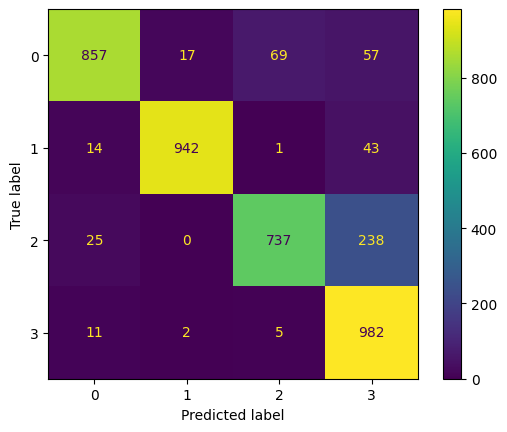

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4]
63/63 [==============================] - 0s 3ms/step
Epoch 1/100
47/47 [==============================] - 2s 23ms/step - loss: 0.0857 - accuracy: 0.8112 - val_loss: 0.1011 - val_accuracy: 0.7786
Epoch 2/100
47/47 [==============================] - 1s 17ms/step - loss: 0.0193 - accuracy: 0.9703 - val_loss: 0.1064 - val_accuracy: 0.7624
Epoch 3/100
47/47 [==============================] - 1s 17ms/step - loss: 0.0113 - accuracy: 0.9855 - val_loss: 0.1067 - val_accuracy: 0.7606
Epoch 4/100
47/47 [==============================] - 1s 17ms/step - loss: 0.0079 - accuracy: 0.9918 - val_loss: 0.1098 - val_accuracy: 0.7464
Epoch 5/100
47/47 [==============================] - 1s 16ms/step - loss: 0.0056 - accuracy: 0.9950 - val_loss: 0.1110 - val_accuracy: 0.7420
Epoch 6/100
47/47 [==============================] - 1s 16m

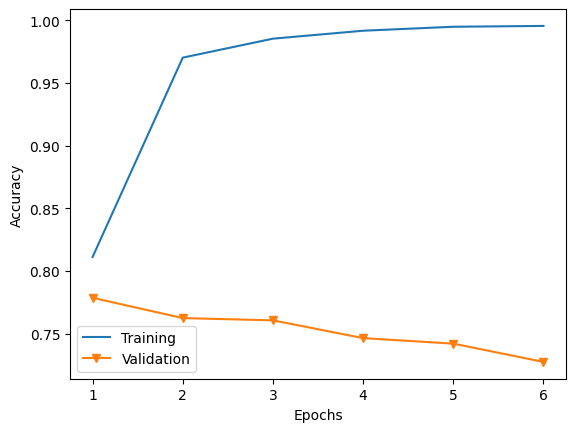

Epoch 1/10
20/20 [==============================] - 1s 58ms/step - loss: 0.0210 - recon_loss: 0.0189 - kl_loss: 0.0046 - decoder_accuracy: 0.7984
Epoch 2/10
20/20 [==============================] - 1s 54ms/step - loss: 0.0197 - recon_loss: 0.0185 - kl_loss: 0.0041 - decoder_accuracy: 0.7976
Epoch 3/10
20/20 [==============================] - 1s 52ms/step - loss: 0.0192 - recon_loss: 0.0186 - kl_loss: 0.0016 - decoder_accuracy: 0.7992
Epoch 4/10
20/20 [==============================] - 1s 56ms/step - loss: 0.0188 - recon_loss: 0.0186 - kl_loss: 0.0013 - decoder_accuracy: 0.7940
Epoch 5/10
20/20 [==============================] - 1s 53ms/step - loss: 0.0196 - recon_loss: 0.0184 - kl_loss: 0.0030 - decoder_accuracy: 0.6272
Epoch 6/10
20/20 [==============================] - 1s 59ms/step - loss: 0.0187 - recon_loss: 0.0184 - kl_loss: 0.0018 - decoder_accuracy: 0.8000
Epoch 6: early stopping
157/157 [==============================] - 1s 5ms/step
              precision    recall  f1-score  

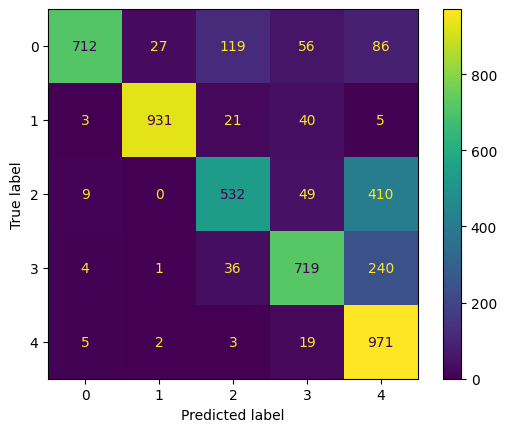

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5]
79/79 [==============================] - 0s 3ms/step
Epoch 1/100
51/51 [==============================] - 2s 24ms/step - loss: 0.1116 - accuracy: 0.6888 - val_loss: 0.1115 - val_accuracy: 0.6890
Epoch 2/100
51/51 [==============================] - 1s 15ms/step - loss: 0.0407 - accuracy: 0.8980 - val_loss: 0.1180 - val_accuracy: 0.6627
Epoch 3/100
51/51 [==============================] - 1s 17ms/step - loss: 0.0332 - accuracy: 0.9132 - val_loss: 0.1242 - val_accuracy: 0.6388
Epoch 4/100
51/51 [==============================] - 1s 16ms/step - loss: 0.0303 - accuracy: 0.9188 - val_loss: 0.1289 - val_accuracy: 0.6235
Epoch 5/100
51/51 [==============================] - 1s 15ms/step - loss: 0.0291 - accuracy: 0.9206 - val_loss: 0.1326 - val_accuracy: 0.6137
Epoch 6/100
51/51 [==============================] - 1s 

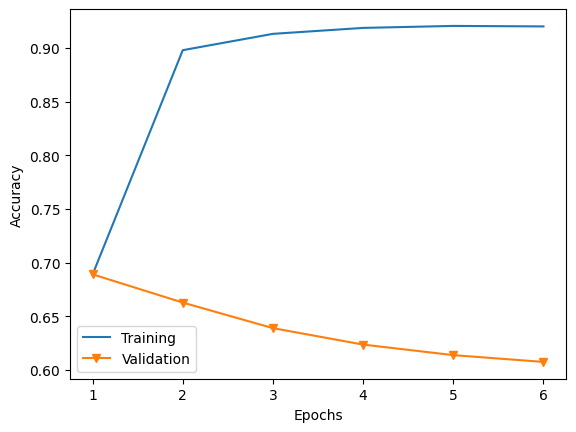

Epoch 1/10
20/20 [==============================] - 1s 60ms/step - loss: 0.0229 - recon_loss: 0.0217 - kl_loss: 0.0054 - decoder_accuracy: 0.6490
Epoch 2/10
20/20 [==============================] - 1s 59ms/step - loss: 0.0214 - recon_loss: 0.0206 - kl_loss: 0.0022 - decoder_accuracy: 0.8020
Epoch 3/10
20/20 [==============================] - 1s 62ms/step - loss: 0.0208 - recon_loss: 0.0202 - kl_loss: 0.0019 - decoder_accuracy: 0.6867
Epoch 4/10
20/20 [==============================] - 1s 60ms/step - loss: 0.0207 - recon_loss: 0.0203 - kl_loss: 0.0016 - decoder_accuracy: 0.8327
Epoch 5/10
20/20 [==============================] - 1s 58ms/step - loss: 0.0207 - recon_loss: 0.0199 - kl_loss: 0.0039 - decoder_accuracy: 0.8333
Epoch 6/10
20/20 [==============================] - 1s 60ms/step - loss: 0.0209 - recon_loss: 0.0198 - kl_loss: 0.0028 - decoder_accuracy: 0.8333
Epoch 7/10
20/20 [==============================] - 1s 59ms/step - loss: 0.0203 - recon_loss: 0.0199 - kl_loss: 0.0028 - dec

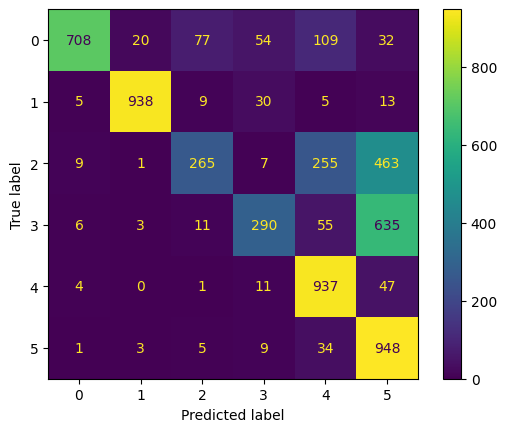

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6]
94/94 [==============================] - 0s 3ms/step
Epoch 1/100
55/55 [==============================] - 3s 26ms/step - loss: 0.0792 - accuracy: 0.7491 - val_loss: 0.0958 - val_accuracy: 0.6883
Epoch 2/100
55/55 [==============================] - 1s 16ms/step - loss: 0.0295 - accuracy: 0.9124 - val_loss: 0.1007 - val_accuracy: 0.6689
Epoch 3/100
55/55 [==============================] - 1s 17ms/step - loss: 0.0249 - accuracy: 0.9233 - val_loss: 0.1034 - val_accuracy: 0.6549
Epoch 4/100
55/55 [==============================] - 1s 19ms/step - loss: 0.0237 - accuracy: 0.9256 - val_loss: 0.1053 - val_accuracy: 0.6467
Epoch 5/100
55/55 [==============================] - 1s 16ms/step - loss: 0.0227 - accuracy: 0.9261 - val_loss: 0.1072 - val_accuracy: 0.6379
Epoch 6/100
55/55 [==============================] - 

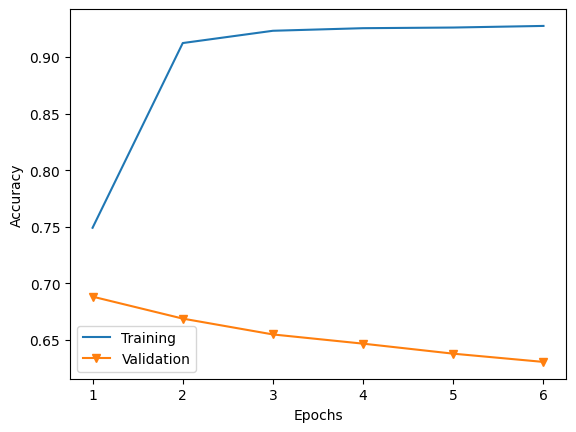

Epoch 1/10
20/20 [==============================] - 1s 66ms/step - loss: 0.0214 - recon_loss: 0.0194 - kl_loss: 0.0044 - decoder_accuracy: 0.8354
Epoch 2/10
20/20 [==============================] - 1s 67ms/step - loss: 0.0193 - recon_loss: 0.0185 - kl_loss: 0.0021 - decoder_accuracy: 0.8466
Epoch 3/10
20/20 [==============================] - 1s 62ms/step - loss: 0.0189 - recon_loss: 0.0184 - kl_loss: 0.0014 - decoder_accuracy: 0.7720
Epoch 4/10
20/20 [==============================] - 1s 75ms/step - loss: 0.0191 - recon_loss: 0.0184 - kl_loss: 0.0030 - decoder_accuracy: 0.7691
Epoch 5/10
20/20 [==============================] - 1s 67ms/step - loss: 0.0193 - recon_loss: 0.0182 - kl_loss: 0.0033 - decoder_accuracy: 0.8394
Epoch 6/10
20/20 [==============================] - 1s 64ms/step - loss: 0.0187 - recon_loss: 0.0183 - kl_loss: 0.0024 - decoder_accuracy: 0.7146
Epoch 7/10
20/20 [==============================] - 1s 63ms/step - loss: 0.0194 - recon_loss: 0.0181 - kl_loss: 0.0044 - dec

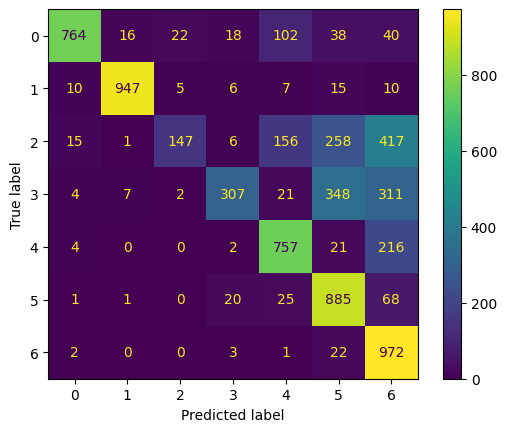

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7]
110/110 [==============================] - 1s 4ms/step
Epoch 1/100
59/59 [==============================] - 3s 25ms/step - loss: 0.0676 - accuracy: 0.7517 - val_loss: 0.1014 - val_accuracy: 0.6185
Epoch 2/100
59/59 [==============================] - 1s 20ms/step - loss: 0.0148 - accuracy: 0.9764 - val_loss: 0.1057 - val_accuracy: 0.6041
Epoch 3/100
59/59 [==============================] - 1s 16ms/step - loss: 0.0060 - accuracy: 0.9940 - val_loss: 0.1108 - val_accuracy: 0.5816
Epoch 4/100
59/59 [==============================] - 1s 17ms/step - loss: 0.0036 - accuracy: 0.9976 - val_loss: 0.1157 - val_accuracy: 0.5590
Epoch 5/100
59/59 [==============================] - 1s 17ms/step - loss: 0.0027 - accuracy: 0.9981 - val_loss: 0.1202 - val_accuracy: 0.5376
Epoch 6/100
59/59 [=============================

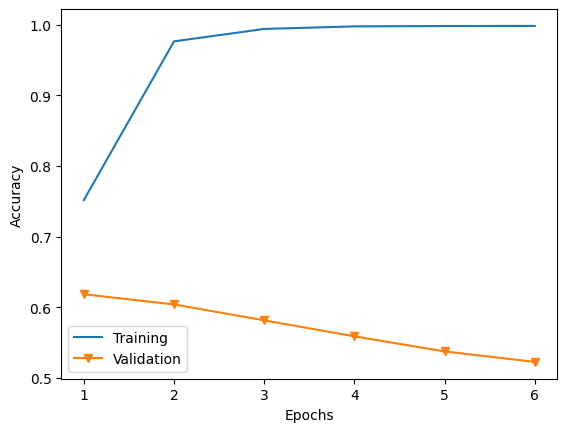

Epoch 1/10
20/20 [==============================] - 2s 77ms/step - loss: 0.0195 - recon_loss: 0.0175 - kl_loss: 0.0024 - decoder_accuracy: 0.8210
Epoch 2/10
20/20 [==============================] - 1s 75ms/step - loss: 0.0179 - recon_loss: 0.0168 - kl_loss: 0.0028 - decoder_accuracy: 0.7510
Epoch 3/10
20/20 [==============================] - 1s 68ms/step - loss: 0.0174 - recon_loss: 0.0167 - kl_loss: 0.0028 - decoder_accuracy: 0.7500
Epoch 4/10
20/20 [==============================] - 1s 73ms/step - loss: 0.0170 - recon_loss: 0.0167 - kl_loss: 0.0023 - decoder_accuracy: 0.8642
Epoch 5/10
20/20 [==============================] - 1s 72ms/step - loss: 0.0182 - recon_loss: 0.0173 - kl_loss: 0.0046 - decoder_accuracy: 0.8750
Epoch 6/10
20/20 [==============================] - 1s 67ms/step - loss: 0.0181 - recon_loss: 0.0167 - kl_loss: 0.0043 - decoder_accuracy: 0.7785
Epoch 7/10
20/20 [==============================] - 1s 68ms/step - loss: 0.0170 - recon_loss: 0.0164 - kl_loss: 0.0028 - dec

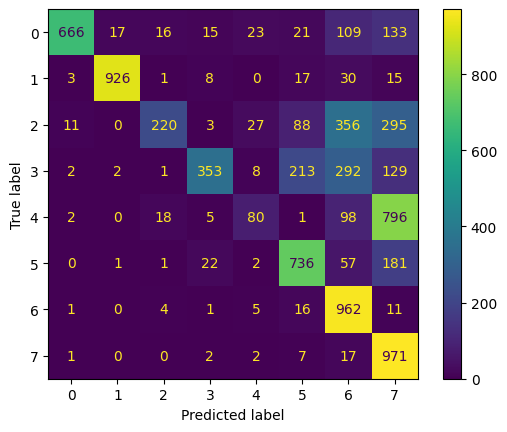

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8]
125/125 [==============================] - 0s 3ms/step
Epoch 1/100
63/63 [==============================] - 2s 23ms/step - loss: 0.0426 - accuracy: 0.8363 - val_loss: 0.0982 - val_accuracy: 0.5892
Epoch 2/100
63/63 [==============================] - 1s 16ms/step - loss: 0.0054 - accuracy: 0.9930 - val_loss: 0.1034 - val_accuracy: 0.5599
Epoch 3/100
63/63 [==============================] - 1s 17ms/step - loss: 0.0028 - accuracy: 0.9964 - val_loss: 0.1080 - val_accuracy: 0.5343
Epoch 4/100
63/63 [==============================] - 1s 16ms/step - loss: 0.0022 - accuracy: 0.9971 - val_loss: 0.1109 - val_accuracy: 0.5146
Epoch 5/100
63/63 [==============================] - 1s 16ms/step - loss: 0.0017 - accuracy: 0.9977 - val_loss: 0.1135 - val_accuracy: 0.4988
Epoch 6/100
63/63 [==========================

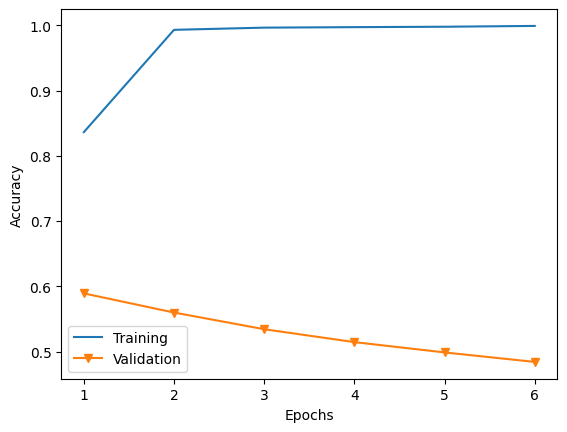

Epoch 1/10
20/20 [==============================] - 2s 85ms/step - loss: 0.0176 - recon_loss: 0.0152 - kl_loss: 0.0055 - decoder_accuracy: 0.5776
Epoch 2/10
20/20 [==============================] - 2s 83ms/step - loss: 0.0152 - recon_loss: 0.0143 - kl_loss: 0.0029 - decoder_accuracy: 0.8889
Epoch 3/10
20/20 [==============================] - 2s 78ms/step - loss: 0.0152 - recon_loss: 0.0143 - kl_loss: 0.0032 - decoder_accuracy: 0.8889
Epoch 4/10
20/20 [==============================] - 2s 79ms/step - loss: 0.0147 - recon_loss: 0.0145 - kl_loss: 0.0017 - decoder_accuracy: 0.8889
Epoch 5/10
20/20 [==============================] - 1s 77ms/step - loss: 0.0143 - recon_loss: 0.0139 - kl_loss: 0.0018 - decoder_accuracy: 0.7811
Epoch 6/10
20/20 [==============================] - 2s 83ms/step - loss: 0.0143 - recon_loss: 0.0139 - kl_loss: 0.0017 - decoder_accuracy: 0.8849
Epoch 7/10
20/20 [==============================] - 2s 87ms/step - loss: 0.0147 - recon_loss: 0.0140 - kl_loss: 0.0025 - dec

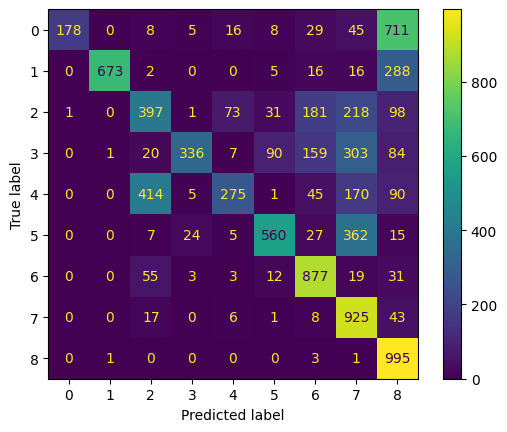

---------------------------------------------------------------------------

--------------------------------------------------------------------------- Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
141/141 [==============================] - 0s 3ms/step
Epoch 1/100
67/67 [==============================] - 3s 21ms/step - loss: 0.0262 - accuracy: 0.8980 - val_loss: 0.0917 - val_accuracy: 0.5666
Epoch 2/100
67/67 [==============================] - 1s 18ms/step - loss: 0.0028 - accuracy: 0.9962 - val_loss: 0.0962 - val_accuracy: 0.5383
Epoch 3/100
67/67 [==============================] - 1s 16ms/step - loss: 0.0017 - accuracy: 0.9985 - val_loss: 0.1011 - val_accuracy: 0.5059
Epoch 4/100
67/67 [==============================] - 1s 17ms/step - loss: 0.0012 - accuracy: 0.9993 - val_loss: 0.1037 - val_accuracy: 0.4893
Epoch 5/100
67/67 [==============================] - 1s 17ms/step - loss: 9.2404e-04 - accuracy: 0.9994 - val_loss: 0.1054 - val_accuracy: 0.4811
Epoch 6/100
67/67 [===================

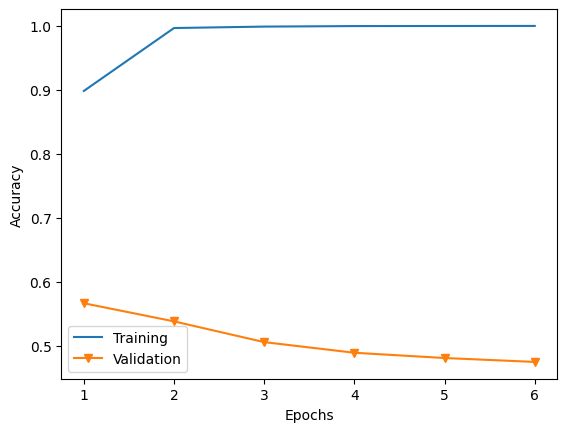

Epoch 1/10
20/20 [==============================] - 2s 89ms/step - loss: 0.0138 - recon_loss: 0.0125 - kl_loss: 0.0033 - decoder_accuracy: 0.9000
Epoch 2/10
20/20 [==============================] - 2s 87ms/step - loss: 0.0132 - recon_loss: 0.0121 - kl_loss: 0.0051 - decoder_accuracy: 0.9466
Epoch 3/10
20/20 [==============================] - 2s 99ms/step - loss: 0.0131 - recon_loss: 0.0115 - kl_loss: 0.0048 - decoder_accuracy: 1.0000
Epoch 4/10
20/20 [==============================] - 2s 85ms/step - loss: 0.0121 - recon_loss: 0.0116 - kl_loss: 0.0022 - decoder_accuracy: 0.9000
Epoch 5/10
20/20 [==============================] - 2s 94ms/step - loss: 0.0118 - recon_loss: 0.0116 - kl_loss: 0.0015 - decoder_accuracy: 0.9000
Epoch 6/10
20/20 [==============================] - 2s 82ms/step - loss: 0.0117 - recon_loss: 0.0114 - kl_loss: 0.0016 - decoder_accuracy: 0.9000
Epoch 7/10
20/20 [==============================] - 2s 84ms/step - loss: 0.0123 - recon_loss: 0.0116 - kl_loss: 0.0021 - dec

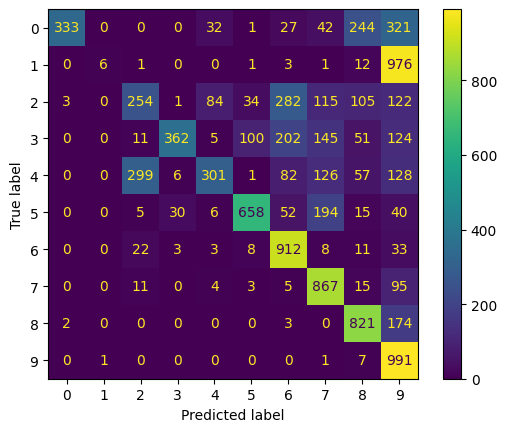

---------------------------------------------------------------------------



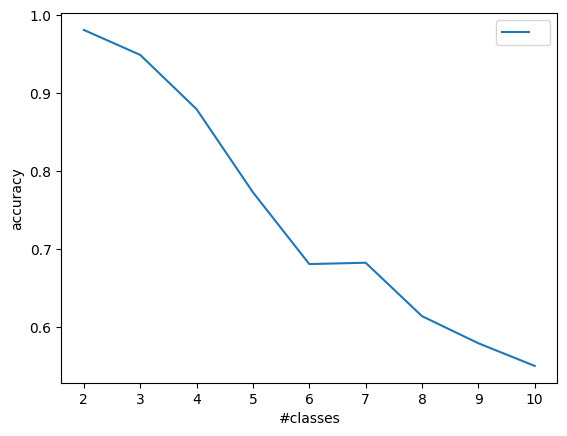

[0.981,
 0.949,
 0.8795,
 0.773,
 0.681,
 0.6827142857142857,
 0.61425,
 0.5795555555555556,
 0.5505]

In [10]:
continually_learn(
    class_num=10, 
    load_dataset_fn=load_cifar10, 
    load_dataset_fn_kwargs={"onehot_labels": True, "preprocess": ""}, 
    remove_prev_classes=True, 
    keep_same_model=True, 
    tuned_model_path=os.path.join(hyperas_path, "cifar10_dnn_model_00.h5"), 
    compile_args=get_compile_args(
        optimizer=optimizers.Adam(learning_rate=5e-5), 
        loss=MaskedLoss(loss_type="mae")
    ), 
    use_vae=True, 
    vae_kwargs={
        "train_num": 10_000,
        "samples_per_class": 500,
    },
)